In [1]:
!rm -rf /content/fashn-vton-1.5
!git clone https://github.com/fashn-AI/fashn-vton-1.5.git /content/fashn-vton-1.5

Cloning into '/content/fashn-vton-1.5'...
remote: Enumerating objects: 92, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 92 (delta 20), reused 13 (delta 13), pack-reused 67 (from 1)
Receiving objects: 100% (92/92), 334.44 KiB | 47.78 MiB/s, done.
Resolving deltas: 100% (29/29), done.


In [2]:
import os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [3]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

In [4]:
%cd /content/fashn-vton-1.5

/content/fashn-vton-1.5


In [5]:
!pip install -U pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 99.1 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [6]:
!pip install -e .

Obtaining file:///content/fashn-vton-1.5
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.3/220.3 MB 155.8 MB/s  0:00:01
  Building editable for fashn-vton (pyproject.toml) ... done
  Created wheel for fashn-vton: filename=fashn_vton-1.5.0-0.editable-py3-none-any.whl size=5770 sha256=682632ad8962e614aae04ddcd4761da602ec69f2f39e85e868211b448ede27af
  Stored in directory: /tmp/pip-ephem-wheel-cache-6mgkfey6/wheels/83/85/d4/003a2789df48fea4fd69c5093b73b4495d75e045a364d41756
Successfully built fashn-vton
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [fashn-vton]


In [7]:
!pip install fastapi uvicorn python-multipart pyngrok nest_asyncio python-dotenv pillow

In [8]:
!pip uninstall -y onnxruntime
!pip uninstall -y onnxruntime-gpu
!pip install onnxruntime-gpu==1.20.1

Found existing installation: onnxruntime-gpu 1.27.0
Uninstalling onnxruntime-gpu-1.27.0:
  Successfully uninstalled onnxruntime-gpu-1.27.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.5/291.5 MB 110.0 MB/s  0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [onnxruntime-gpu]


In [9]:
!pip install -q fastapi uvicorn python-multipart pyngrok nest_asyncio python-dotenv pillow

In [10]:
%%writefile /content/gpu_api.py
import subprocess
import os
import uuid
import traceback

import torch
from PIL import Image

from fastapi import FastAPI, UploadFile, File, Form, HTTPException
from fastapi.responses import FileResponse, JSONResponse

from fashn_vton import TryOnPipeline

# ==========================================================
# FASTAPI
# ==========================================================

app = FastAPI(
    title="WearFashion GPU API",
    version="1.0.0"
)

# ==========================================================
# PATHS
# ==========================================================

WEIGHTS_DIR = "/content/fashn_weights"

INPUT_DIR = "/content/input"
OUTPUT_DIR = "/content/output"

PERSON_DIR = os.path.join(INPUT_DIR, "person")
GARMENT_DIR = os.path.join(INPUT_DIR, "garment")

os.makedirs(PERSON_DIR, exist_ok=True)
os.makedirs(GARMENT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==========================================================
# LOAD MODEL
# ==========================================================

print("================================")
print("Loading FASHN-VTON Pipeline...")
print("================================")

pipeline = TryOnPipeline(
    weights_dir=WEIGHTS_DIR,
    device="cuda"
)

print("================================")
print("Pipeline Loaded Successfully")
print("================================")

# ==========================================================
# ROOT
# ==========================================================

@app.get("/")
def root():
    return {
        "status": "running"
    }


@app.get("/health")
def health():
    return {
        "status": "healthy",
        "cuda": torch.cuda.is_available()
    }

# ==========================================================
# TRYON
# ==========================================================

@app.post("/tryon")
async def generate_tryon(
    person: UploadFile = File(...),
    garment: UploadFile = File(...),
    category: str = Form("tops"), # Make category optional with a default fallback
    garment_photo_type: str = Form("flat-lay")
   ):

    try:

        print("================================")
        print("TRYON REQUEST RECEIVED")
        print("================================")

        print("Person :", person.filename)
        print("Garment :", garment.filename)
        print("Category :", category)
        print("Garment Type :", garment_photo_type)

        category = category.strip().lower()

        if category in [
            "shirt",
            "tshirt",
            "t-shirt",
            "top",
            "tops",
            "hoodie",
            "jacket",
            "blazer",
            "sweater"
        ]:
            category = "tops"

        elif category in [
            "pant",
            "pants",
            "jeans",
            "bottom",
            "bottoms",
            "trouser"
        ]:
            category = "bottoms"

        elif category in [
            "dress",
            "gown",
            "one-pieces"
        ]:
            category = "one-pieces"

        else:
            raise HTTPException(
                status_code=400,
                detail=f"Unsupported category : {category}"
            )

        person_path = os.path.join(
            PERSON_DIR,
            f"{uuid.uuid4()}.png"
        )

        garment_path = os.path.join(
            GARMENT_DIR,
            f"{uuid.uuid4()}.png"
        )

        with open(person_path, "wb") as f:
            f.write(await person.read())

        with open(garment_path, "wb") as f:
            f.write(await garment.read())

        person_image = Image.open(person_path).convert("RGB")

        IMAG_OUTPUT = "/content/IMAGDressing/generated"
        os.makedirs(IMAG_OUTPUT, exist_ok=True)

        print("Running IMAGDressing...")

        subprocess.run(
        [
        "python",
        "/content/IMAGDressing/inference_IMAGdressing.py",
        "--model_ckpt",
        "/content/IMAGDressing/models/IMAGDressing-v1_512.pt",
        "--cloth_path",
        garment_path,
        "--output_path",
        IMAG_OUTPUT,
    ],
        check=True
      )

    generated_path = os.path.join(
      IMAG_OUTPUT,
      os.path.basename(garment_path)
      )
print("Generated garment:", generated_path)

garment_image = Image.open(generated_path).convert("RGB")
print("Person Size :", person_image.size)
print("Garment Size :", garment_image.size)

result = pipeline(

            person_image=person_image,

            garment_image=garment_image,

            category=category,

            garment_photo_type=garment_photo_type,

            num_samples=1,

            num_timesteps=30,

            guidance_scale=1.5,

            seed=42,

            segmentation_free=True
        )

output = result.images[0]

output_path = os.path.join(
            OUTPUT_DIR,
            f"{uuid.uuid4()}.png"
        )

output.save(output_path)

print("TRYON COMPLETED")


return FileResponse(
            output_path,
            media_type="image/png",
            filename="result.png"
        )

except HTTPException:
        raise

    except Exception:

        traceback.print_exc()

        return JSONResponse(
            status_code=500,
            content={
                "error": traceback.format_exc()
            }
        )

Writing /content/gpu_api.py


In [11]:
import nest_asyncio
nest_asyncio.apply()

print("AsyncIO Ready")

AsyncIO Ready


In [12]:
!pip install -q pyngrok fastapi uvicorn nest_asyncio python-multipart

In [13]:
%cd /content/fashn-vton-1.5
!python scripts/download_weights.py --weights-dir /content/fashn_weights

/content/fashn-vton-1.5



model.safetensors: downloading bytes:   0% 5.79M/1.94G [00:02<12:26, 2.60MB/s]
model.safetensors: downloading bytes:   1% 16.1M/1.94G [00:02<03:42, 8.67MB/s,  550kB/s  ]
model.safetensors: downloading bytes:   1% 25.9M/1.94G [00:02<02:11, 14.6MB/s, 1.87MB/s  ]
model.safetensors: downloading bytes:   2% 35.2M/1.94G [00:02<01:26, 22.0MB/s, 2.42MB/s  ]
model.safetensors: downloading bytes:   2% 43.0M/1.94G [00:02<01:06, 28.7MB/s, 3.26MB/s  ]
model.safetensors: downloading bytes:   3% 53.5M/1.94G [00:02<00:54, 34.7MB/s, 4.34MB/s  ]
model.safetensors: downloading bytes:   3% 65.3M/1.94G [00:03<00:45, 41.1MB/s, 5.43MB/s  ]
model.safetensors: downloading bytes:   4% 75.5M/1.94G [00:03<00:36, 50.8MB/s, 5.87MB/s  ]
model.safetensors: downloading bytes:   5% 92.8M/1.94G [00:03<00:25, 73.5MB/s, 6.76MB/s  ]
model.safetensors: downloading bytes:   6% 107M/1.94G [00:03<00:20, 88.1MB/s, 8.30MB/s  ] 
model.safetensors: downloading bytes:   8% 155M/1.94G [00:03<00:19, 91.6MB/

In [14]:
!git clone https://github.com/muzishen/IMAGDressing.git

Cloning into 'IMAGDressing'...
remote: Enumerating objects: 1288, done.
remote: Counting objects: 100% (148/148), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 1288 (delta 132), reused 61 (delta 58), pack-reused 1140 (from 3)
Receiving objects: 100% (1288/1288), 48.82 MiB | 14.56 MiB/s, done.
Resolving deltas: 100% (459/459), done.


In [15]:
%cd IMAGDressing

/content/fashn-vton-1.5/IMAGDressing


In [16]:
!pip install torchvision==0.18.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 140.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.1/779.1 MB 35.5 MB/s  0:00:09
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 57.7 MB/s  0:00:04
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 196.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 212.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 50.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 36.9 MB/s  0:00:08
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 159.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 173.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 163.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 103.8 MB/s  0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 MB 167.0 MB/s  0:00:01
  Attempting uninstall: nvidia-nvtx-cu12
    Found existing instal

In [17]:
!pip uninstall -y peft accelerate

Found existing installation: peft 0.19.1
Uninstalling peft-0.19.1:
  Successfully uninstalled peft-0.19.1
Found existing installation: accelerate 1.14.0
Uninstalling accelerate-1.14.0:
  Successfully uninstalled accelerate-1.14.0


In [18]:
!pip install accelerate==0.31.0
!pip install peft==0.11.1

In [19]:
%cd /content/IMAGDressing

!pip install -U pip
!pip install -r requirements.txt
!pip install huggingface_hub

[Errno 2] No such file or directory: '/content/IMAGDressing'
/content/fashn-vton-1.5/IMAGDressing
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 55.7 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 65.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.8/119.8 MB 110.4 MB/s  0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 85.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 100.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 189.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 48.2 MB/s  0:00:06
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 106.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 142.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 59.9 MB/s  0:00:00
  

KeyboardInterrupt: 

In [18]:
import os

# 1. Clone the repository if it hasn't been cloned yet
if not os.path.exists('/content/IMAGDressing'):
    print("Cloning IMAGDressing repository...")
    !git clone https://github.com/muzishen/IMAGDressing.git /content/IMAGDressing
else:
    print("IMAGDressing repository already exists.")

# 2. Change directory
%cd /content/IMAGDressing

# 3. Filter requirements to avoid Colab environment conflicts
if os.path.exists('requirements.txt'):
    print("requirements.txt found. Filtering dependencies...")
    with open('requirements.txt', 'r') as f:
        lines = f.readlines()

    filtered_lines = []
    for line in lines:
        # Ignore nvidia-specific CUDA 11 packages and deepspeed (takes too long to compile)
        if 'nvidia' not in line and 'deepspeed' not in line:
            # Relax version checks
            filtered_lines.append(line.replace('==', '>='))

    with open('requirements_colab.txt', 'w') as f:
        f.writelines(filtered_lines)

    !pip install -U pip
    !pip install -r requirements_colab.txt
else:
    print("requirements.txt not found! Installing default dependencies manually...")
    !pip install -U pip
    !pip install diffusers transformers accelerate einops bitsandbytes

# 4. Install huggingface_hub
!pip install huggingface_hub

IMAGDressing repository already exists.
/content/IMAGDressing
requirements.txt not found! Installing default dependencies manually...


In [20]:
# 3. Change directory to /content/IMAGDressing
import os
if not os.path.exists('/content/IMAGDressing'):
    print("Cloning IMAGDressing repository...")
    !git clone https://github.com/muzishen/IMAGDressing.git /content/IMAGDressing
else:
    print("IMAGDressing repository already exists.")

%cd /content/IMAGDressing

# 4. Clean requirements and install them to avoid Colab env conflicts
if os.path.exists('requirements.txt'):
    print("Installing dependencies...")
    with open('requirements.txt', 'r') as f:
        lines = f.readlines()

    filtered_lines = []
    for line in lines:
        if 'nvidia' not in line and 'deepspeed' not in line:
            filtered_lines.append(line.replace('==', '>='))

    with open('requirements_colab.txt', 'w') as f:
        f.writelines(filtered_lines)

    !pip install -U pip
    !pip install -r requirements_colab.txt
    !pip install huggingface_hub
    print("Installation complete!")
else:
    print("requirements.txt not found. Please run Step 1 first.")

IMAGDressing repository already exists.
/content/IMAGDressing
requirements.txt not found. Please run Step 1 first.


In [21]:
import os

# 1. Verify if repository files are actually present. If not, clone and restore them.
# This will NOT delete or overwrite your downloaded models/ directory.
required_file = '/content/IMAGDressing/requirements.txt'
if not os.path.exists(required_file):
    print("Repository files are missing! Safely restoring them...")
    !git clone https://github.com/muzishen/IMAGDressing.git /tmp/IMAGDressing_repo
    os.makedirs('/content/IMAGDressing', exist_ok=True)
    !cp -rn /tmp/IMAGDressing_repo/* /content/IMAGDressing/
    !rm -rf /tmp/IMAGDressing_repo
    print("Repository code successfully restored!")
else:
    print("Repository code is already present.")

# 2. Link model file from models/ to ckpt/ so the scripts can find it
os.makedirs('/content/IMAGDressing/ckpt', exist_ok=True)
model_name = "IMAGDressing-v1_512.pt"
src_model = f"/content/IMAGDressing/models/{model_name}"
dst_model = f"/content/IMAGDressing/ckpt/{model_name}"

if os.path.exists(src_model) and not os.path.exists(dst_model):
    print(f"Linking {model_name} to ckpt/ folder...")
    os.symlink(src_model, dst_model)
    print("Model linked successfully!")
elif os.path.exists(dst_model):
    print("Model is already linked/present in ckpt/ folder.")
else:
    print(f"Warning: {src_model} not found in models/ folder. Please check if your download completed successfully.")

# 3. Change directory to /content/IMAGDressing
%cd /content/IMAGDressing

# 4. Filter requirements to avoid conflicts and install them
if os.path.exists('requirements.txt'):
    print("Filtering and installing dependencies...")
    with open('requirements.txt', 'r') as f:
        lines = f.readlines()

    filtered_lines = []
    for line in lines:
        if 'nvidia' not in line and 'deepspeed' not in line:
            filtered_lines.append(line.replace('==', '>='))

    with open('requirements_colab.txt', 'w') as f:
        f.writelines(filtered_lines)

    !pip install -U pip
    !pip install -r requirements_colab.txt
    !pip install huggingface_hub
    print("Setup completed successfully!")
else:
    print("Error: requirements.txt is still missing! Please double check your Colab environment files.")

Repository files are missing! Safely restoring them...
Cloning into '/tmp/IMAGDressing_repo'...
remote: Enumerating objects: 1288, done.
remote: Counting objects: 100% (148/148), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 1288 (delta 132), reused 61 (delta 58), pack-reused 1140 (from 3)
Receiving objects: 100% (1288/1288), 48.82 MiB | 17.99 MiB/s, done.
Resolving deltas: 100% (459/459), done.
Repository code successfully restored!
Linking IMAGDressing-v1_512.pt to ckpt/ folder...
Model linked successfully!
/content/IMAGDressing
Filtering and installing dependencies...
Setup completed successfully!


In [22]:
!huggingface-cli download feishen29/IMAGDressing \
    --local-dir /content/IMAGDressing/models \
    --disable-progress-bar

usage: huggingface-cli <command> [<args>]
huggingface-cli: error: unrecognized arguments: --disable-progress-bar


In [28]:
!pip uninstall -y huggingface_hub
!pip install huggingface_hub==0.19.4

Found existing installation: huggingface_hub 0.36.2
Uninstalling huggingface_hub-0.36.2:
  Successfully uninstalled huggingface_hub-0.36.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fashn-vton 1.5.0 requires huggingface_hub>=0.20.0, but you have huggingface-hub 0.19.4 which is incompatible.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.19.4 which is incompatible.
sentence-transformers 5.6.0 requires huggingface-hub>=0.23.0, but you have huggingface-hub 0.19.4 which is incompatible.
sentence-transformers 5.6.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.


In [37]:
!python /content/IMAGDressing/inference_IMAGdressing.py \
  --model_ckpt /content/IMAGDressing/models/IMAGDressing-v1_512.pt \
  --cloth_path /content/IMAGDressing/assets/images/garment/1.jpg \
  --output_path /content/IMAGDressing/generated

/usr/local/lib/python3.12/dist-packages/diffusers/utils/outputs.py:63: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/diffusers/utils/outputs.py:63: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/diffusers/utils/outputs.py:63: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/diffusers/utils/outputs.py:63: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
============

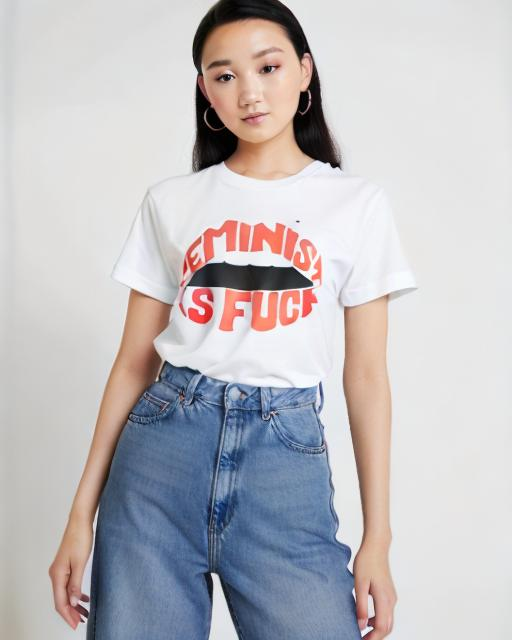

In [38]:
from PIL import Image

Image.open("/content/IMAGDressing/generated/1.jpg")

In [44]:
pip uninstall -y starlette fastapi

Found existing installation: starlette 1.3.1
Uninstalling starlette-1.3.1:
  Successfully uninstalled starlette-1.3.1
Found existing installation: fastapi 0.139.0
Uninstalling fastapi-0.139.0:
  Successfully uninstalled fastapi-0.139.0


In [45]:
pip install fastapi==0.139.0 starlette==0.47.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 113.9 MB/s  0:00:00
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.8.0
    Uninstalling typing_extensions-4.8.0:
      Successfully uninstalled typing_extensions-4.8.0
  Attempting uninstall: pydantic-core
    Found existing installation: pydantic_core 2.18.1
    Uninstalling pydantic_core-2.18.1:
      Successfully uninstalled pydantic_core-2.18.1
  Attempting uninstall: pydantic
    Found existing installation: pydantic 2.7.0
    Uninstalling pydantic-2.7.0:
      Successfully uninstalled pydantic-2.7.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [fastapi]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fashn-vton 1.5.0 requires huggingface_hub>=0.20.0, but you have huggingface-hub 0.19.4 which is incompatible.
gradio 6.20.0 requires huggingface-hub<2.0,

In [39]:
from pyngrok import ngrok

ngrok.set_auth_token("3GgTA1ga8WRNMGAJgxmk8C2E8EL_7Xi8jnLQEi3WBt5G3Rz2f")

In [46]:
from pyngrok import ngrok

ngrok.kill()      # purana tunnel band
public_url = ngrok.connect(8000)

print(public_url.public_url)

https://mutt-udder-easter.ngrok-free.dev


In [47]:
%cd /content
!uvicorn gpu_api:app --host 0.0.0.0 --port 8000

/content
Loading FASHN-VTON Pipeline...
TryOnPipeline - INFO - Using device: cuda
TryOnPipeline - INFO - Using dtype: torch.bfloat16
TryOnPipeline - INFO - Loading TryOnModel from /content/fashn_weights/model.safetensors
TryOnPipeline - INFO - TryOnModel loaded
TryOnPipeline - INFO - Loading DWPose from /content/fashn_weights/dwpose
2026-07-29 10:53:40.678744755 [W:onnxruntime:, session_state.cc:1168 VerifyEachNodeIsAssignedToAnEp] Some nodes were not assigned to the preferred execution providers which may or may not have an negative impact on performance. e.g. ORT explicitly assigns shape related ops to CPU to improve perf.
2026-07-29 10:53:40.678787389 [W:onnxruntime:, session_state.cc:1170 VerifyEachNodeIsAssignedToAnEp] Rerunning with verbose output on a non-minimal build will show node assignments.
TryOnPipeline - INFO - DWPose loaded
TryOnPipeline - INFO - Loading FashnHumanParser
TryOnPipeline - INFO - FashnHumanParser loaded
Pipeline Loaded Successfully
INFO:     Started server